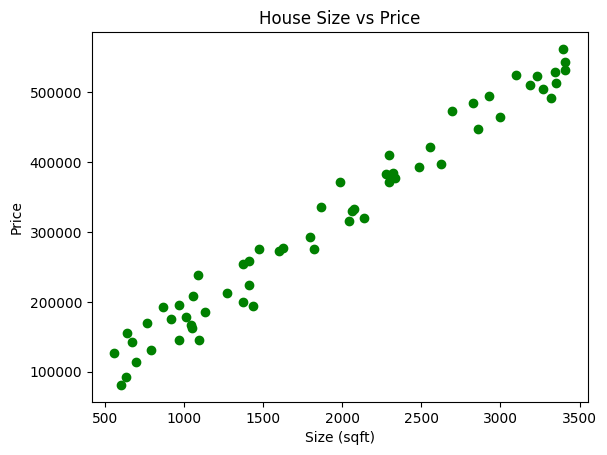

Coefficient for Size_sqft: 150.97
Coefficient for Bedrooms: 8826.12
Intercept: 1290.41
Mean Absolute Error: 16733.98
R² Score: 0.98


,Size_sqft,Bedrooms,Actual_Price,Predicted_Price,Difference,Deal_Flag
0,1624.0,5,277000.0,290595.0,-13595.0,Fair Price
5,968.0,4,195000.0,182733.0,12267.0,Fair Price
36,1414.0,3,258000.0,241239.0,16761.0,Overpriced
45,2488.0,3,393000.0,403380.0,-10380.0,Fair Price
13,1137.0,1,186000.0,181769.0,4231.0,Fair Price
54,2294.0,5,410000.0,391745.0,18255.0,Overpriced
33,3347.0,5,529000.0,550715.0,-21715.0,Good Deal
48,2140.0,2,320000.0,342017.0,-22017.0,Good Deal
12,2997.0,1,465000.0,462572.0,2428.0,Fair Price
57,1088.0,5,239000.0,209676.0,29324.0,Overpriced


In [2]:
# ============================================================
# House Price Prediction with "Fair Deal or Overpriced?" Flag
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------
df = pd.read_csv('/content/house_data.csv')

# ------------------------------------------------------------
# 2. Visualize the raw data
# ------------------------------------------------------------
plt.scatter(df['Size_sqft'], df['Price'], color='green')
plt.xlabel('Size (sqft)')
plt.ylabel('Price')
plt.title('House Size vs Price')
plt.show()

# ------------------------------------------------------------
# 3. Split into training and test sets
# ------------------------------------------------------------
X = df[['Size_sqft', 'Bedrooms']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 4. Train the multiple linear regression model
# ------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient for Size_sqft: {model.coef_[0]:.2f}")
print(f"Coefficient for Bedrooms: {model.coef_[1]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

# ------------------------------------------------------------
# 5. Evaluate on the test set
# ------------------------------------------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# ------------------------------------------------------------
# 6. Fair Deal / Overpriced flag (innovation layer)
# ------------------------------------------------------------
results = X_test.copy()
results['Actual_Price'] = y_test
results['Predicted_Price'] = y_pred.round(0)
results['Difference'] = (results['Actual_Price'] - results['Predicted_Price']).round(0)

THRESHOLD = 15000  # ~5-10% of typical price; adjust as needed

def flag_deal(diff):
    if diff > THRESHOLD:
        return "Overpriced"
    elif diff < -THRESHOLD:
        return "Good Deal"
    else:
        return "Fair Price"

results['Deal_Flag'] = results['Difference'].apply(flag_deal)
results

In [ ]:
!pip install gradio -q

import gradio as gr

feature_names = list(X.columns)  # or train1.columns, depending on which version you're submitting

def predict_price(*args):
    *feature_values, actual_price = args
    input_data = pd.DataFrame([feature_values], columns=feature_names)
    predicted = model.predict(input_data)[0]  # or clf.predict(...) for the kc_house_data version
    diff_percent = ((actual_price - predicted) / predicted) * 100

    if diff_percent > 10:
        flag = "🔴 Overpriced"
    elif diff_percent < -10:
        flag = "🟢 Underpriced (Good Deal)"
    else:
        flag = "🟡 Fair Deal"

    return f"Predicted Price: ${predicted:,.2f}", f"Difference: {diff_percent:.2f}%", flag

inputs = [gr.Number(label=col) for col in feature_names] + [gr.Number(label="Actual Listed Price ($)")]

interface = gr.Interface(
    fn=predict_price,
    inputs=inputs,
    outputs=[gr.Textbox(label="Predicted Price"), gr.Textbox(label="Difference"), gr.Textbox(label="Deal Flag")],
    title="House Price Predictor & Fair Deal Checker"
)

interface.launch(share=True)